# Merton model credit risk


# Index:

## Presentation
  	1. Problem Definition
  		1.1 How will we solve it?
## I. Environment Setup and Data Preparation
	Step 1: Setting Up the Environment with Necessary Libraries
	Step 2: Parameter Definition
	Step 3: Standardizing Financial Values to Billions
	Step 4: Importing Data
	Step 5: Selecting a Company for Analysis
	Step 6: Filtering and Extracting Company Information
	Step 7: Retrieving Historical Stock Prices
## II. Financial Analysis and Calculations
	Step 8: Calculating Logarithmic Returns and Volatility
	Step 9: User Input for Maturity and Debt
	Step 10: Creating a Financial Summary Table
	Step 11: Displaying the Financial Summary and Minimizing Functions
	Step 12: Calculating the Probability of Default (PD)
## III. Sensitivity and Function Evaluation
	Step 13: Evaluating Different Values of Asset Volatility (sv) and Market Value (V0)
	Step 14: Evaluating the Function with Different Market Values (V0) and Fixed Volatility(sv)
	Step 15: Evaluating the Function Over a Grid of Values and Visualizing the Results
## IV. Data Visualization
	Step 16: Creating an Interactive 3D Surface Plot Using Plotly
	Step 17: Creating a Contour Plot to Emphasize the Minimum Value
## V. Advanced Analysis and Customization
	Step 18: Calculating Additional Results in Merton's Model
	Step 19: Creating a Custom Function to Calculate the Probability of Default
	Step 20: Sensitivity Analysis of Probability of Default with Respect to Debt and Maturity
## VI. Conclusions

___________________________________________________________________________________

# Credit Risk Analysis Algorithm

### 1. Problem Definition 

The objective is to develop an algorithm in R to perform credit risk analysis based on the Merton model for any public firm. The challenge lies in automating the process for a large number of companies while ensuring the analysis is comprehensive and accurate. The level of automation and depth of analysis are designed to support real-world credit risk workflows in banking and asset management.

  ### 1.1 How will we solve it?

We will develop an automated R algorithm to perform credit risk analysis using the Merton model for firms based on a dataset of the S&P 500. The algorithm will retrieve stock data, calculate logarithmic returns and volatility, and apply the Merton model to compute the Probability of Default (PD) by solving key equations for market value ($V_0$) and volatility ($\sigma_V$). It will automate the generation of credit risk metrics, perform sensitivity analysis on debt and maturity, and provide visualizations like 3D surface plots and contour maps. 
 
 
 __________________________________________________________________________________

Designed to evaluate _**firms in the S&P 500**_ using the Merton model, this guide will show you how to input the necessary financial data, understand the key steps in the analysis, and generate comprehensive reports with ease. Whether you're evaluating a single firm or multiple companies, _this guide will help you navigate and maximize the capabilities of the algorithm_.

# I. Environment Setup and Data Preparation

## **Step 1:** Setting Up the Environment with Necessary Libraries

The first part of the algorithm focuses on setting up the environment by installing and loading the required libraries. These libraries are essential for different functions related to financial analysis, data manipulation, statistical modeling, and visualization.

In [127]:
##Libraries
install.packages("gmodels")
install.packages("vembedr")
install.packages("Sim.DiffProc")
install.packages("rvest")
install.packages("tidyverse")
install.packages("quantmod")
install.packages("Quandl")

#
library(knitr)
library(plotly)
library(magrittr)
library(Sim.DiffProc)
library(scatterplot3d)
library(rvest)
library(tidyverse)
library(readr)
library(quantmod)
# Logistic models del loan analisis
library(gmodels) # CrossTable()
library(ggplot2)
library(tidyr) # gather()
library(dplyr)
library(pROC) # roc
library(vembedr)

The following package(s) will be installed:
- gmodels [2.19.1]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing gmodels ...                        OK [linked from cache]
The following package(s) will be installed:
- vembedr [0.1.5]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing vembedr ...                        OK [linked from cache]
The following package(s) will be installed:
- Sim.DiffProc [4.9]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing Sim.DiffProc ...                   OK [linked from cache]
The following package(s) will be installed:
- rvest [1

## **Step 2:** Parameter Definition
This section defines key variables that are integral to the Merton model, which is used for credit risk analysis and estimating the likelihood of default of a firm. 

In [128]:
# E0 <- (en millones) # Value of the equity as today, this is market capitalization.
# se <- (beta) # Stock return volatility.
# rf <- (tasa en decimales) # Risk-free rate.
# TT <- (se busca el maturity a evaluar) # Maturity.
# D <- (en millones) # Value of the debt. The Bloomberg function DDIS is useful.

## Step 3: Standardizing Financial Values to Billions
The function "convertir_a_billones" is designed to convert financial values expressed in different units (millions, billions, or trillions) into a consistent unit: billions.

### **How It Works**

1.`Input Cleaning:`
The function removes any spaces from the input to ensure the number can be processed correctly.

2.`Unit Detection and Conversion:`
The function checks the suffix of the input string to determine the unit.

3.`Error Handling:`
If the input does not match any of the expected formats (ending in "M", "B", "T", or a plain numeric), the function raises an error to alert the user that the format is invalid.

4.`Output:`
The function returns the value converted into billions, regardless of the original unit.


In [129]:
convertir_a_billones <- function(valor) {
  valor <- gsub(" ", "", valor)
  if (grepl("B$", valor)) {
    num <- as.numeric(sub("B", "", valor)) 
    num_en_billones <- num 
  } else if (grepl("M$", valor)) {
    num <- as.numeric(sub("M", "", valor)) 
    num_en_billones <- num / 1e3 
  } else if (grepl("T$", valor)) {
    num <- as.numeric(sub("T", "", valor))  
    num_en_billones <- num * 1e3
  } else if (grepl("^[0-9.]+$", valor)) {
    num_en_billones <- as.numeric(valor) / 1e9
  } else {
    stop("El valor no tiene un formato válido (debe terminar en 'M', 'B' o 'T').")
  }
  return(num_en_billones)
}

## Step 4: Importing Data
In this part, the algorithm imports a CSV file containing data on companies, from the S&P 500 index, into R. This dataset will be used for further analysis, such as calculating financial metrics or evaluating company performance.

In [130]:
companies_data <- read_csv("sp500_companies.csv", show_col_types = FALSE)


## Step 5: Selecting a Company for Analysis
In this section, the program will ask you to input the ticker symbol of the company you want to analyze. 

Once you enter the ticker, the program will automatically convert it to uppercase to ensure consistency when processing the data.

In [110]:
# Ask the user for the ticker they want to analyze
FRM <- readline(prompt = "Ingresa el ticker de la empresa:")
# Convert the entered ticker to uppercase to ensure consistency
FRM <- toupper(FRM)

Ingresa el ticker de la empresa:

## Step 6: Filtering and Extracting Company Information
At this point, the program filters the dataset to find the company corresponding to the ticker symbol entered by the user. It checks if the company exists in the dataset, retrieves the market capitalization (equity value), and converts it into billions using the previously defined function.

In [111]:

# Filter the company with the entered symbol
company_info <- companies_data[companies_data$Symbol == FRM, ]
# Verify that the company was found
if (nrow(company_info) == 0) {
  print("El ticker ingresado no se encontró en la base de datos.")
} else {
# Extract the market cap value and display it
	
# EQUITY
  E0 <- company_info$Marketcap
  print(paste("El valor del equity (Market cap) para", FRM, "es:", E0))
}

# Convert the variable E0
E0 <- convertir_a_billones(E0)

[1] "El valor del equity (Market cap) para CAT es: 190269128704"


## Step 7: Retrieving Historical Stock Prices
Through this step, the program will retrieve the historical stock prices for the company you selected based on the ticker symbol you entered earlier. It will collect the stock prices from the last three years using data from Yahoo Finance and focus specifically on the adjusted closing prices.

In [112]:
# Retrieve historical prices of the provided ticker (using data from the last three year)
getSymbols(FRM, src = "yahoo", from = Sys.Date() - 3*365, to = Sys.Date(), auto.assign = TRUE)

precios_data <- get(FRM)

adjusted_col <- paste(FRM, "Adjusted", sep = ".")

if (adjusted_col %in% colnames(precios_data)) {
  precios <- precios_data[, adjusted_col]
} else {
  stop(paste("No se encontró la columna 'Adjusted' para el ticker", FRM))
}

[1] "CAT"

# II. Financial Analysis and Calculations

## Step 8: Calculating Logarithmic Returns and Volatility 
At this moment, the program will calculate the logarithmic returns of the stock's adjusted prices, followed by the daily volatility and the annualized volatility. Additionally, the program defines the risk-free rate, which is essential for financial modeling and risk analysis.

In [113]:
# Logarithmic Returns Calculation
retornos <- diff(log(precios))

# Daily Volatility Calculation
vol_diaria <- sd(retornos, na.rm = TRUE)

# Annualized Volatility (multiply by the square root of 252 trading days)
se <- vol_diaria * sqrt(252)

# Risk-Free Rate
rf1 <- 3.96
rf <- as.numeric(sub("%", "", rf1)) / 100

## Step 9: User Input for Maturity and Debt
In this part, the program will ask you to provide two critical financial inputs: the maturity of the debt and the value of the debt for the company you are analyzing. These inputs are essential for calculating risk and evaluating the financial health of the company.

In [114]:
# User Input for Maturity
TT <- as.numeric(readline(prompt = "Ingresa el Maturity de la empresa:"))

# User Input for Debt
D <- readline(prompt = "Ingresa la deuda de la empresa:")
D <- convertir_a_billones(D)

Ingresa el Maturity de la empresa:26
Ingresa la deuda de la empresa:36B


## Step 10: Creating a Financial Summary Table
In this method, the program consolidates all the financial parameters you have provided and calculated into a clear, organized financial summary table. This table presents key values such as market capitalization, volatility, risk-free rate, maturity, and debt, which are crucial for further financial analysis and modeling.

In [115]:
tabla_financiera <- data.frame(
  Parameter = c("E0 (Market Capitalization)", "e (volatility)", "rf (Risk-free rate)", "TT (Maturity)", "D (Debt)"),
  Value = c(E0, se, rf, TT, D) 
)

## Step 11: Displaying the Financial Summary and Minimizing Functions
In this stage of the process, the program will first display the financial summary table in an easy-to-read format and then calculate the market value and volatility of the company’s assets by solving two key financial equations. This process involves optimizing the results to find the most accurate estimates.

In [116]:
# Display the table in a user-friendly format using kable()
kable(tabla_financiera, col.names = c("Parameter", "Value"), align = "c")

eq24.3 <- function(V0, sv) { 
  ((V0 * pnorm((log(V0 / D) + (rf + sv^2 / 2) * TT) / (sv * sqrt(TT))) -
  D * exp(-rf * TT) * pnorm(((log(V0 / D) +
  (rf + sv^2 / 2) * TT) / (sv * sqrt(TT))) - sv * sqrt(TT)) - E0)) }
eq24.4 <- function(V0, sv) { 
  ((pnorm((log(V0 / D) + (rf + sv^2 / 2) * TT) / (sv * sqrt(TT))) *
      sv * V0 - se * E0)) }

# Footnote 10 indicates that we should minimize F(x,y)^2+G(x,y)^2
min.footnote10 <- function(x) 
  (eq24.3(x[1], x[2]))^2 + (eq24.4(x[1], x[2]))^2

# The minimization leads to the values of V0 and sv.
V0_sv <- optim(c(1, 1), min.footnote10)

# Define the values as parameters.
V0 <- V0_sv$par[1]
sv <- V0_sv$par[2]
kable(data.frame("Market value" = V0, 
                 "Volatility" = sv), 
      caption = "Assets.")



|         Parameter          |    Value    |
|:--------------------------:|:-----------:|
| E0 (Market Capitalization) | 190.2691287 |
|       e (volatility)       |  0.2928537  |
|    rf (Risk-free rate)     |  0.0396000  |
|       TT (Maturity)        | 26.0000000  |
|          D (Debt)          | 36.0000000  |



Table: Assets.

| Market.value| Volatility|
|------------:|----------:|
|     202.5591|  0.2761194|

## Step 12: Calculating the Probability of Default (PD)
At this instance, the program calculates the Probability of Default (PD) for the company based on the values of the market value of assets ($V_0$), volatility ($\sigma_V$), and other financial parameters. The probability of default is a crucial metric in credit risk analysis, showing the likelihood that the company will be unable to meet its debt obligations by the maturity date.

In [117]:
PD <- function(V0, sv) { 
  pnorm(-(((log(V0 / D) + (rf + sv^2 / 2) * TT) / 
             (sv * sqrt(TT))) - sv * sqrt(TT))) }

pd <- PD(V0, sv)
pd_porcentaje <- round(pd * 100, 2)
print(paste("Probability of default at", TT, "years is:", pd_porcentaje, "%"))

[1] "Probability of default at 26 years is: 10.49 %"


# III. Sensitivity and Function Evaluation

## Step 13: Evaluating Different Values of Asset Volatility ($\sigma_V$) and Market Value ($V_0$)
In this step, the program will explore how changes in the volatility ($\sigma_V$) and market value of assets ($V_0$) affect the financial model. By fixing one variable and varying the other, you can observe how sensitive the company's risk profile is to changes in these key parameters.

In [118]:
# Now fix V0, and evaluate different sv values.
sv.seq <- seq(0, 2, length.out = 100)
V0.rep <- rep(V0, 100)

# Fix sv and evaluate different values of V0.
V0.seq <- seq(from = 0, to = 2.5*(E0), length.out = 100)
sv.rep <- rep(sv, 100)

## Step 14: Evaluating the Function with Different Market Values ($V_0$) and Fixed Volatility ($\sigma_V$)
In this part, the program evaluates how changes in the market value of assets ($V_0$) affect the company’s financial risk, while keeping the volatility ($\sigma_V$) fixed. This is done by applying the defined function to different values of $V_0$ and observing the resulting output.

In [119]:
# Function to be evaluated.
FG <- function(V0, sv) { (eq24.3(V0, sv))^2 + (eq24.4(V0, sv))^2 }
# Apply the function with fixed sv and different V0 values.
FG.V0 <- mapply(FG, V0.seq, sv.rep)

## Step 15: Evaluating the Function Over a Grid of Values and Visualizing the Results
Now the program evaluates the function FG() over a grid of values for both market value ($V_0$) and volatility ($\sigma_V$). It creates a 3D surface plot to visualize how the objective function behaves across different combinations of these parameters. The program also evaluates the function with fixed market value ($V_0$) and varying volatility ($\sigma_V$), producing further insights into the sensitivity of the financial model.

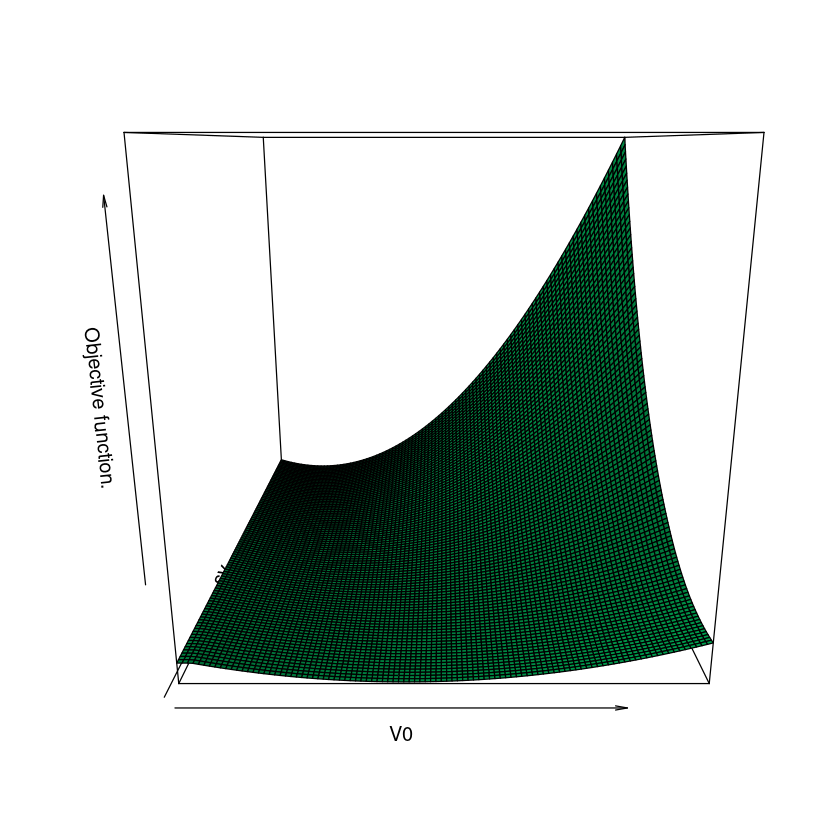

In [120]:
# Outer evaluates the function for each combination of the vectors.

z <- outer(V0.seq, sv.seq, FG) # z is now 100x100 matrix.
persp(V0.seq, sv.seq, z, col = "springgreen", shade = 0, xlab = "V0",
      ylab = "sv", zlab = "Objective function.")

# Evaluate the function with these parameters.
FG.sv <- mapply(FG, V0.rep, sv.seq)

# IV. Data Visualization

## Step 16: Creating an Interactive 3D Surface Plot Using Plotly
In the current step, the program generates an interactive 3D surface plot using the plotly library. This plot visualizes the impact of asset volatility ($\sigma_V$) on market value ($V_0$), based on the results of the objective function. The plot allows you to explore how different combinations of volatility and market value influence the financial model.

In [121]:

plot_ly(type = "surface" , x = sv.seq, y = V0.seq , z = z, 
        colorscale = list(c(0, "red"), c(0.2, "yellow"), c(1, "green"))) %>%
layout(
  title = list(
    text = "Impact of Asset Volatility on Asset Value in Merton's Model",
    yanchor = "top", 
    pad = list(b = 200)  
  ),
  scene = list(
    xaxis = list(title = "Assets volatility"), 
    yaxis = list(title = "Assets"), 
    zaxis = list(title = "f=F^2+G^2")
  )
) %>%
hide_colorbar()

HTML widgets cannot be represented in plain text (need html)

## Step 17: Creating a Contour Plot to Emphasize the Minimum Value
At this moment, the program generates a contour plot to visually represent the relationship between market value ($V_0$) and volatility ($\sigma_V$), emphasizing the minimum value of the objective function. The plot highlights the areas where the function reaches its lowest point, providing further insight into the sensitivity of the model.

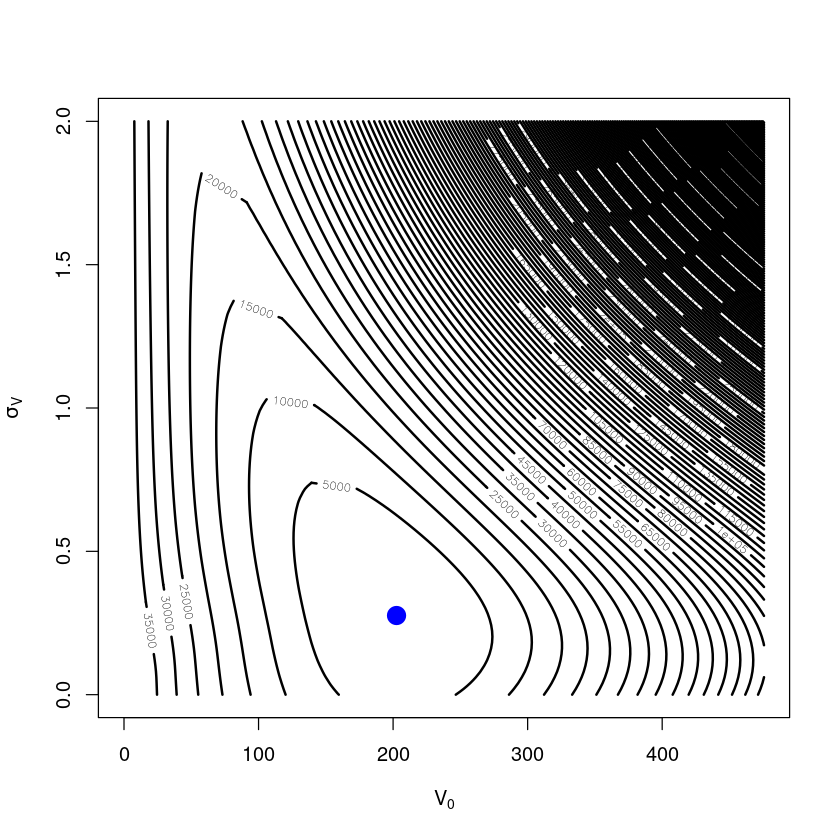

In [122]:
# The nlevels is high to emphasize the minimum value in blue.
contour(V0.seq, sv.seq, z, xlab = expression(paste(V[0])), 
        ylab = expression(paste(sigma[V])), 
        lwd = 2, nlevels = 300)
points(V0, sv, pch = 19, col = "blue", cex = 2)

# V. Advanced Analysis and Customization

## Step 18: Calculating Additional Results in Merton's Model
Now, the program calculates several additional metrics from Merton’s model that provide further insight into the financial health and risk of the company. These metrics include the market value of debt, the present value of promised debt payments, the expected loss, and the recovery rate. The results are then displayed in a table.

In [123]:
# Other results in the Merton's model.
market_value_debt <- V0 - E0
pv_promised_payment_debt <- D * exp(-rf * TT)
Expected_Loss <- (pv_promised_payment_debt - market_value_debt) /
  pv_promised_payment_debt
recovery_rate <- 1 - (Expected_Loss / pd)
ans <- data.frame(market_value_debt, pv_promised_payment_debt, 
                  Expected_Loss, recovery_rate, pd)
kable(t(ans), caption = "Other results in the Merton's model.")



Table: Other results in the Merton's model.

|                         |           |
|:------------------------|----------:|
|market_value_debt        | 12.2899667|
|pv_promised_payment_debt | 12.8573925|
|Expected_Loss            |  0.0441323|
|recovery_rate            |  0.5791626|
|pd                       |  0.1048677|

## Step 19: Creating a Custom Function to Calculate the Probability of Default
In this method, the program defines a custom function `PDFUNCION` that simplifies the process of calculating the Probability of Default (PD) using Merton’s model. This function encapsulates the key components of the model and can be applied to any set of inputs related to a company's financial situation.

In [124]:
PDFUNCION <- function(E0, se, rf, TT, D) { 
  eq24.3 <- function(V0, sv) { 
  ((V0 * pnorm((log(V0 / D) + (rf + sv^2 / 2) * TT) / (sv * sqrt(TT))) -
  D * exp(-rf * TT) * pnorm(((log(V0 / D) +
  (rf + sv^2 / 2) * TT) / (sv * sqrt(TT))) - sv * sqrt(TT)) - E0)) }
eq24.4 <- function(V0, sv) { 
  ((pnorm((log(V0 / D) + (rf + sv^2 / 2) * TT) / (sv * sqrt(TT))) *
      sv * V0 - se * E0)) }
  min.footnote10 <- function(x) 
  (eq24.3(x[1], x[2]))^2 + (eq24.4(x[1], x[2]))^2
V0_sv <- optim(c(1, 1), min.footnote10)
V0 <- V0_sv$par[1]
sv <- V0_sv$par[2]
pd <- pnorm(-(((log(V0 / D) + (rf + sv^2 / 2) * TT) /
          (sv * sqrt(TT))) - sv * sqrt(TT)))
pd }

## Step 20: Sensitivity Analysis of Probability of Default with Respect to Debt and Maturity
In this step, the program performs a sensitivity analysis to evaluate how changes in the company’s debt value (D) and maturity (TT) affect the Probability of Default (PD). This is achieved by applying the custom `PDFUNCION()` over a range of debt values and varying the time to maturity, and visualizing the results through a plot.

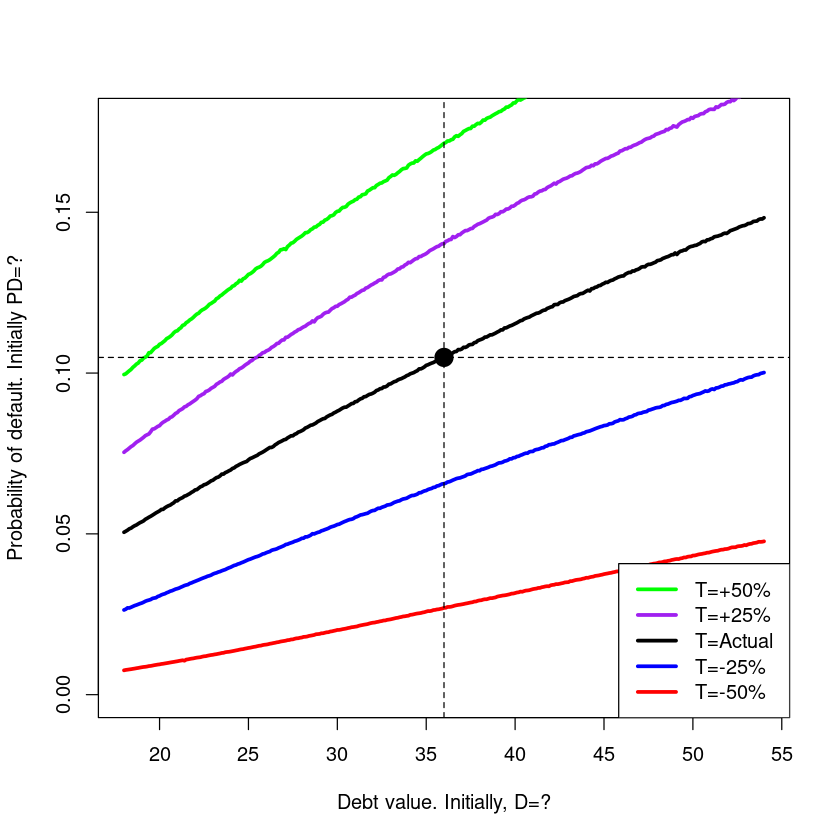

In [125]:
D.seq <- seq(from = D - (0.5 * D), to = D + (0.5 * D), by = 0.1)

yseq <- seq(from = 0, to = pd + (pd * 0.7), length.out = length(D.seq))


T1 <- mapply(PDFUNCION, E0, se, rf, TT - (0.5 * TT), D.seq)
T2 <- mapply(PDFUNCION, E0, se, rf, TT - (0.25 * TT), D.seq)
T3 <- mapply(PDFUNCION, E0, se, rf, TT, D.seq)
T4 <- mapply(PDFUNCION, E0, se, rf, TT + (0.25 * TT), D.seq)
T5 <- mapply(PDFUNCION, E0, se, rf, TT + (0.5 * TT), D.seq)

leg3 <- c("T=+50%", "T=+25%", "T=Actual", "T=-25%", "T=-50%")

# Definir un vector de colores
colors <- c("green", "purple", "black", "blue", "red")

plot(D.seq, yseq,
     xlab = "Debt value. Initially, D=?",
     ylab = "Probability of default. Initially PD=?",
	type = "n")
lines(D.seq, T5, col = "green", lwd = 3)
lines(D.seq, T4, col = "purple", lwd = 3)
lines(D.seq, T3, col = "black", lwd = 3)
lines(D.seq, T2, col = "blue", lwd = 3)
lines(D.seq, T1, col = "red", lwd = 3)
abline(v = D, lty = 2)
abline(h = PDFUNCION(E0, se, rf, TT, D), lty = 2)
legend("bottomright", legend = leg3, lwd = rep(3, 5), col = colors, 
       bg = "white")
points(D, PDFUNCION(E0, se, rf, TT, D), pch = 19, cex = 2)

In [126]:
print(pd)

[1] 0.1048677
